### Speech Recognition with SpeechLM - wav2vec2 

This script demonstrates automatic speech recognition (ASR) using Hugging Face's Transformers library with Facebook's wav2vec2 model. It handles audio preprocessing and transcription for both short and long recordings.

Key Libraries Used:

    transformers: Provides ASR pipeline and wav2vec2 model

    torch: Enables GPU acceleration

    soundfile: Reads audio files

    librosa: Handles audio preprocessing (mono conversion, resampling)

Code Logic and Flow

The pipeline:

    Checks for GPU availability

    Loads pre-trained wav2vec2 ASR model

    Loads and preprocesses audio:

        Converts stereo to mono

        Resamples to 16kHz (model requirement)

    Transcribes short audio directly or long audio with chunking

    Outputs transcription results

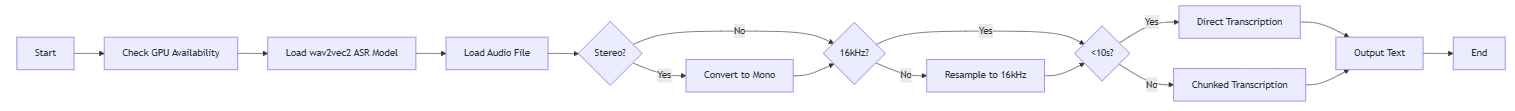

Step-by-Step Code Breakdown

1. Hardware Configuration

    Automatically detects and uses CUDA GPU if available

    Falls back to CPU otherwise

2. Model Initialization

    Loads facebook/wav2vec2-base-960h pre-trained model

    Uses Transformers pipeline API for simplified inference

3. Audio Loading & Preprocessing

    Reads WAV file using soundfile

    Converts stereo to mono via channel averaging

    Resamples to 16kHz (wav2vec2's required sample rate)

    Handles file loading exceptions gracefully

4. Adaptive Transcription

    Short audio (<10s): Processes entire clip at once

    Long audio: Uses 10-second chunks with 2-second overlap

    Chunking prevents memory issues with long recordings

    Overlap maintains context continuity

5. Result Output

    Prints raw transcription text

    Includes audio metadata (duration, sample rate)

Connecting to Lecture Concepts

This implementation demonstrates:

    Transfer Learning: Leverages pre-trained wav2vec2 model

    Audio Preprocessing: Mandatory format conversion for model input

    Computational Efficiency: Automatic GPU utilization

    Real-World Handling: Adaptive chunking for long recordings

    Sample Rate Sensitivity: 16kHz requirement for this ASR model

    Error Resilience: Graceful exception handling

    End-to-End Pipeline: From raw audio to transcribed text

    Model Limitations: wav2vec2-base struggles with accents/noisy audio

    Practical Deployment: Ready-to-use transcription solution

    Context Preservation: Stride overlap maintains speech continuity   

In [ ]:
!pip install librosa

In [10]:
# Step 1: Install necessary libraries
# !pip install transformers torch soundfile librosa

import torch
import soundfile as sf
import librosa
from transformers import pipeline

# Check if CUDA (GPU support) is available, otherwise use CPU
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Step 2: Load a pre-trained ASR pipeline
print("Loading ASR pipeline...")
asr_pipeline = pipeline(
    "automatic-speech-recognition",
    model="facebook/wav2vec2-base-960h",
    device=device
)
print("ASR pipeline loaded.")

# Step 3: Load your local audio file
audio_path = "input_audio.wav" # Replace with your file path here
try:
    audio_input, sampling_rate = sf.read(audio_path)
    print(f"Loaded local file: {audio_path}")
    print(f"Sample rate: {sampling_rate}, Duration: {len(audio_input)/sampling_rate:.2f} seconds.")

    # If stereo, convert to mono
    if audio_input.ndim > 1:
        audio_input = librosa.to_mono(audio_input.T)
    # If sample rate mismatch, resample
    target_sr = asr_pipeline.feature_extractor.sampling_rate
    if sampling_rate != target_sr:
        audio_input = librosa.resample(audio_input, orig_sr=sampling_rate, target_sr=target_sr)
        sampling_rate = target_sr
except Exception as e:
    print(f"Could not load local audio file: {e}")
    audio_input = None

# Step 4: Perform transcription
if audio_input is not None:
    print("Performing transcription...")
    # For short audio, don't use chunking
    audio_duration = len(audio_input) / sampling_rate
    if audio_duration < 10:
        transcription = asr_pipeline(audio_input.copy())
    else:
        transcription = asr_pipeline(audio_input.copy(), chunk_length_s=10, stride_length_s=2)
    print("\nTranscription Result:")
    print(transcription['text'])
else:
    print("No audio input available to transcribe.")

print("\nExample finished.")

Using device: cpu
Loading ASR pipeline...


Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-960h and are newly initialized: ['wav2vec2.masked_spec_embed']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use cpu


ASR pipeline loaded.
Loaded local file: C:\Users\vinit\Desktop\FinFree Project\Courses\Deep learning for Speech language model\1 Introduction to Speech LP & SLMs\1.4 Advantages of Speech Language Models (SpeechLMs)\input_audio.wav
Sample rate: 48000, Duration: 13.61 seconds.
Performing transcription...

Transcription Result:
I THIS ORDIO IS FOR USE IN THE CORDING EXAMPLE FOR THE SPITILELEM COURSE CLERTSEY HOW THIS WORKS

Example finished.


### Example 2 - Speech Emotion Recognition with Transformers

Short Description:
This code performs Speech Emotion Recognition (SER) using a pre-trained Wav2Vec2 model. It loads an audio file, preprocesses it (resampling and mono conversion), and classifies emotions with confidence scores. The workflow demonstrates GPU acceleration, model configuration, and audio processing for speech-based machine learning.

Key Libraries Used:

    transformers: Provides pre-trained models and pipelines for audio classification.

    torch: Enables GPU acceleration and tensor operations.

    soundfile: Reads audio files from disk.

    librosa: Handles audio resampling and channel conversion.

Code Logic and Flow

High-Level Overview:
The script first checks for GPU availability to optimize processing speed. It loads a pre-trained SER model, configures it for the correct sampling rate, then processes an input audio file by resampling to 16kHz and converting stereo to mono. The processed audio is fed into the model to predict top-5 emotions with confidence scores.

Visual Flowchart:

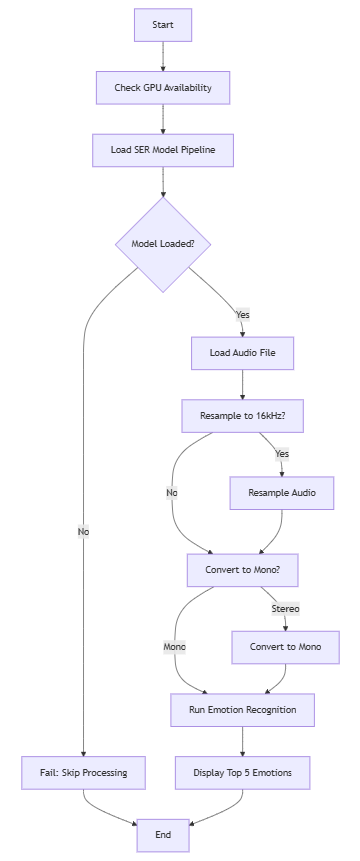

Step-by-Step Code Breakdown

Step 1: Configuration & GPU Setup

    Defines model name (superb/wav2vec2-base-superb-er), target sampling rate (16kHz), and audio file path.

    Auto-detects GPU/CPU to maximize processing speed.

Step 2: SER Model Initialization

    Loads Hugging Face audio-classification pipeline with error handling.

    Automatically fetches the model's required sampling rate from its configuration.

Step 3: Audio Preprocessing

    Reads audio file using soundfile and checks original sampling rate.

    Resamples audio to 16kHz using librosa if needed.

    Converts multi-channel audio to mono for model compatibility.

Step 4: Emotion Recognition

    Passes processed audio to the model for classification.

    Extracts top-5 emotion predictions with confidence scores.

    Prints results with labels and scores formatted to 4 decimal places.

Connecting to the Lecture

This implementation directly applies Speech Language Model (SLM) concepts discussed in lecture:

    Model Specialization: Uses a Wav2Vec2 variant fine-tuned for emotion recognition (SER), showcasing how base SLMs adapt to downstream tasks.

    Audio Preprocessing: Highlights the critical need for input standardization (sampling rate/channels) to match pretrained model requirements, preventing spectral distortion.

    Computational Efficiency: GPU detection demonstrates practical latency reduction for real-time applications.

    Paralinguistic Analysis: Focuses on extracting non-linguistic features (emotion) – a key advantage of SpeechLMs over text-only models discussed in "1.4 Advantages of Speech Language Models".

    Error Propagation: Robust error handling (model/audio load failures) illustrates mitigation strategies for cascade failures in speech processing pipelines.

In [2]:

# Step 1: Install necessary libraries
# !pip install transformers torch soundfile librosa

import torch
from transformers import pipeline
import librosa
import soundfile as sf

# --- Configuration ---
SER_MODEL = "superb/wav2vec2-base-superb-er"
TARGET_SAMPLING_RATE = 16000 # Most Wav2Vec2 models expect 16kHz
AUDIO_PATH = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\1 Introduction to Speech LP & SLMs\1.4 Advantages of Speech Language Models (SpeechLMs)\input_audio.wav"
# ---

# Check if CUDA (GPU support) is available, otherwise use CPU
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Step 2: Load a pre-trained audio classification pipeline for SER
print(f"Loading SER pipeline with model: {SER_MODEL}...")
try:
    ser_pipeline = pipeline(
        "audio-classification",
        model=SER_MODEL,
        device=device
    )
    # Get the expected sampling rate from the feature extractor
    if hasattr(ser_pipeline, 'feature_extractor') and hasattr(ser_pipeline.feature_extractor, 'sampling_rate'):
        TARGET_SAMPLING_RATE = ser_pipeline.feature_extractor.sampling_rate
    print(f"SER pipeline loaded. Expects sampling rate: {TARGET_SAMPLING_RATE} Hz.")
except Exception as e:
    print(f"Error loading SER pipeline: {e}")
    ser_pipeline = None

# Step 3: Load your local audio file
audio_input = None
sampling_rate = None

if ser_pipeline: # Only proceed if pipeline loaded
    print(f"Loading local audio file: {AUDIO_PATH}")
    try:
        audio_input, sampling_rate = sf.read(AUDIO_PATH)
        print(f"Loaded local file. Original SR: {sampling_rate} Hz, Duration: {len(audio_input)/sampling_rate:.2f} seconds.")

        # Resample and convert to mono if necessary
        if sampling_rate != TARGET_SAMPLING_RATE:
            print(f"Resampling audio from {sampling_rate} Hz to {TARGET_SAMPLING_RATE} Hz...")
            audio_input = librosa.resample(audio_input, orig_sr=sampling_rate, target_sr=TARGET_SAMPLING_RATE)
            sampling_rate = TARGET_SAMPLING_RATE
            print("Resampling complete.")

        if audio_input.ndim > 1:
            print("Converting audio to mono...")
            audio_input = librosa.to_mono(audio_input.T if audio_input.shape[0] == min(audio_input.shape) else audio_input)
            print("Mono conversion complete.")

    except Exception as e:
        print(f"Could not load or process local audio file: {e}")
        audio_input = None

# Step 4: Perform emotion recognition
if ser_pipeline and audio_input is not None:
    print("Performing speech emotion recognition...")
    try:
        results = ser_pipeline(audio_input.copy(), top_k=5) # Ask for top 5 predictions

        print("\nEmotion Recognition Results:")
        if results:
            for result in results:
                label = result['label']
                score = result['score']
                print(f"- Emotion: {label}, Score: {score:.4f}")
        else:
            print("No results returned by the pipeline.")

    except Exception as e:
        print(f"Error during emotion recognition: {e}")

elif not ser_pipeline:
    print("Cannot perform SER because the pipeline failed to load.")
else:
    print("Cannot perform SER because audio input was not available.")

print("\nExample 2 finished.")


Using device: cpu
Loading SER pipeline with model: superb/wav2vec2-base-superb-er...


Device set to use cpu


SER pipeline loaded. Expects sampling rate: 16000 Hz.
Loading local audio file: C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\1 Introduction to Speech LP & SLMs\1.4 Advantages of Speech Language Models (SpeechLMs)\input_audio.wav
Loaded local file. Original SR: 48000 Hz, Duration: 13.61 seconds.
Resampling audio from 48000 Hz to 16000 Hz...
Resampling complete.
Performing speech emotion recognition...

Emotion Recognition Results:
- Emotion: neu, Score: 0.8441
- Emotion: hap, Score: 0.1552
- Emotion: ang, Score: 0.0007
- Emotion: sad, Score: 0.0000

Example 2 finished.
